<a href="https://colab.research.google.com/github/laywright/Iris/blob/multiloader-new/Car_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving suv_data.csv to suv_data.csv


In [ ]:
data = pd.read_csv('suv_data.csv')
print(data.shape)
data.head()

(400, 5)


,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [ ]:
data.isnull()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
...,...,...,...,...,...
395,False,False,False,False,False
396,False,False,False,False,False
397,False,False,False,False,False
398,False,False,False,False,False


In [ ]:
X = data.drop('Purchased', axis=1)
X = data.drop('User ID', axis=1)
X = data.drop('Gender', axis=1)
y = data['Purchased']
print(X)


      User ID  Age  EstimatedSalary  Purchased
0    15624510   19            19000          0
1    15810944   35            20000          0
2    15668575   26            43000          0
3    15603246   27            57000          0
4    15804002   19            76000          0
..        ...  ...              ...        ...
395  15691863   46            41000          1
396  15706071   51            23000          1
397  15654296   50            20000          1
398  15755018   36            33000          0
399  15594041   49            36000          1

[400 rows x 4 columns]


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=0)

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train = le.fit_transform(y_train)  # Convert 'Female'/'Male' to 0/1


In [ ]:

from sklearn.linear_model import LogisticRegression
logModel = LogisticRegression()
logModel.fit(X_train, y_train)

LogisticRegression()

In [ ]:
X_test['Gender'] = X_test['Gender'].map({'Male': 1, 'Female': 0})


In [ ]:
y_pred = logModel.predict(X_test)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(y_test, y_pred))

[[42  3]
 [ 1 14]]


In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


Accuracy: 0.9333333333333333


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


ValueError: X has 2 features, but StandardScaler is expecting 3 features as input.

Saving Car prediction.csv to Car prediction.csv
User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64
Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7689 - loss: 0.5802 - val_accuracy: 0.8833 - val_loss: 0.5075
Epoch 2/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8118 - loss: 0.5360 - val_accuracy: 0.8833 - val_loss: 0.4742
Epoch 3/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7806 - loss: 0.5266 - val_accuracy: 0.8833 - val_loss: 0.4470
Epoch 4/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8309 - loss: 0.5224 - val_accuracy: 0.8833 - val_loss: 0.4217
Epoch 5/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7929 - loss: 0.4981 - val_accuracy: 0.8833 - val_loss: 0.3972
Epoch 6/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7888 - loss: 0.5049 - val_accuracy: 0.8833 - val_loss: 0.3754
Epoch 7/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8256 - loss: 0.4545 - val_accuracy: 0.9000 - val_loss: 0.3555
Epoch 8/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8781 - loss: 0.4221 - val_accuracy: 0.9167 - val_loss: 0.3369
Epo

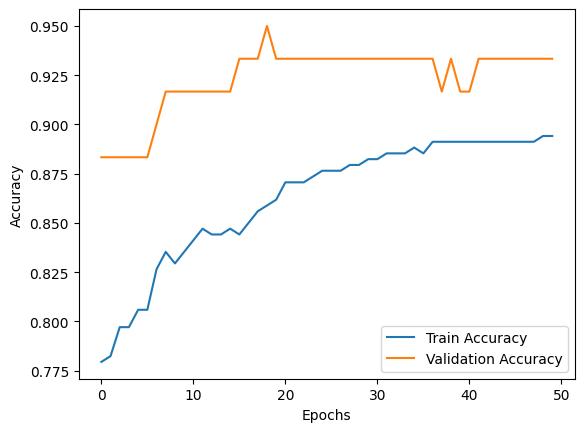

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Upload file
uploaded = files.upload()

# Load dataset
data = pd.read_csv('suv_data.csv')

# Check for missing values
print(data.isnull().sum())

# Encode Gender (if necessary)
data['Gender'] = data['Gender'].map({'Male': 1, 'Female': 0})

# Feature selection (remove unnecessary columns)
X = data.drop(columns=['User ID', 'Purchased'])
y = data['Purchased']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=0)

# Feature scaling (important for neural networks)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Define the Neural Network model
model = Sequential([
    Dense(8, activation='relu', input_shape=(X_train.shape[1],)),  # Hidden layer
    Dense(1, activation='sigmoid')  # Output layer (for binary classification)
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train, epochs=50, batch_size=10, validation_data=(X_test, y_test))

# Make predictions
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)  # Convert probabilities to 0 or 1

# Print predictions
print("Predictions:", y_pred.flatten())

# Evaluate model performance
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

# Plot training history
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


In [ ]:
new_data = np.array([[30,1, 50000]])  # Example: Age = 30, EstimatedSalary = 50000
new_data = scaler.transform(new_data)  # Apply the same scaling
prediction = model.predict(new_data)
print("Prediction:", (prediction > 0.5).astype(int)[0][0])  # Output: 0 or 1


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
Prediction: 0


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
